In [48]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Analyzing Model performance for GLR multi clustered, GLR neighborhoods, GLR districts

this section analyzed the metric diagnostics for the GLR model version that were ran in order

to understand which one better fit the data

In [49]:
# Load the CSV files
# GLR grouped by neighborhood
glr_df = pd.read_csv("../database/predicted_data/glr_predicted.csv")
# GLR with multivariate clustering
glr_multi_df = pd.read_csv("../database/predicted_data/glr_multi_predicted.csv")
# GLR grouped by district
glr_district_df = pd.read_csv("../database/predicted_data/glr_district_predicted.csv")

In [4]:
# Calculate the performance metrics for each model
glr_mae = mean_absolute_error(glr_df["price"], glr_df["PREDICTED"])
glr_rmse = mean_squared_error(glr_df["price"], glr_df["PREDICTED"], squared=False)
glr_r2 = r2_score(glr_df["price"], glr_df["PREDICTED"])

glr_multi_mae = mean_absolute_error(glr_multi_df["price"], glr_multi_df["PREDICTED"])
glr_multi_rmse = mean_squared_error(glr_multi_df["price"], glr_multi_df["PREDICTED"], squared=False)
glr_multi_r2 = r2_score(glr_multi_df["price"], glr_multi_df["PREDICTED"])

glr_district_mae = mean_absolute_error(glr_district_df["price"], glr_district_df["PREDICTED"])
glr_district_rmse = mean_squared_error(glr_district_df["price"], glr_district_df["PREDICTED"], squared=False)
glr_district_r2 = r2_score(glr_district_df["price"], glr_district_df["PREDICTED"])

In [5]:
# Print the results
print("GLR neighbor: MAE={}, RMSE={}, R2={}".format(glr_mae, glr_rmse, glr_r2))
print("GLR multiclustering: MAE={}, RMSE={}, R2={}".format(glr_multi_mae, glr_multi_rmse, glr_multi_r2))
print("GLR district: MAE={}, RMSE={}, R2={}".format(glr_district_mae, glr_district_rmse, glr_district_r2))

GLR neighbor: MAE=30423.962843358757, RMSE=46278.412493550306, R2=0.6666615088218144
GLR multiclustering: MAE=32984.50797245421, RMSE=48538.53658268314, R2=0.6332233562609273
GLR district: MAE=30900.012326041367, RMSE=46853.534510264704, R2=0.6582328907620048


we see here that GLR with neighborhood context performs the best, which we choose for further analysis in the paper

## Baseline vs Neighborhood GLR

Now we can analyse the residuals of the baseline GLR and neighborhood GLR to review

how much the neighborhood GLR has improvement over the baseline approach

In [132]:
# load data
historical_sold = pd.read_csv("../database/yerevan_combined_clean/historical_sold.csv")
glr_baseline_df = pd.read_csv("../database/predicted_data/glr_baseline_predicted.csv")
glr_df = pd.read_csv("../database/predicted_data/glr_predicted.csv")

/var/folders/31/mgjvydd530n_q8xd9pnv0wrc0000gq/T/ipykernel_62393/3546427043.py:2: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  histroical_sold = pd.read_csv("../database/yerevan_combined_clean/historical_sold.csv")


the following version of the filtering and removal of data points is done so that it matches how it would be in ArcGIS

In terms of removing missing value points and ensuring we have enough degrees of freedom to run GLR 

because of too few features or too many explanatory variables.

In [133]:
historical_sold = historical_sold.dropna(subset=['square_meters', 'height', 'walking_distance_to_metro(m)', 'bathroom'])

neighborhood_counts = historical_sold['neighborhood'].value_counts()
neighborhood_df = pd.DataFrame({'neighborhood': neighborhood_counts.index, 'count': neighborhood_counts.values})
neighborhoods_to_remove = neighborhood_df[neighborhood_df['count'] < 9]['neighborhood'].tolist()
historical_sold = historical_sold[~historical_sold['neighborhood'].isin(neighborhoods_to_remove)]

In [134]:
# neighborhood column was left out of independent variables we join it back from the original dataset
glr_baseline_df.sort_values(by=["price"], inplace=True)
glr_df.sort_values(by=["price"], inplace=True)
historical_sold.sort_values(by=["price"], inplace=True)
glr_baseline_df.reset_index(drop=True, inplace=True)
glr_df.reset_index(drop=True, inplace=True)
historical_sold.reset_index(drop=True, inplace=True)

In [135]:
glr_baseline_df = glr_baseline_df.join(historical_sold['neighborhood'])
glr_df = glr_df.join(historical_sold['neighborhood'])

In [136]:
# Calculate the mean predicted price for the baseline approach
baseline_mean_price = glr_baseline_df['PREDICTED'].mean()

# Calculate the mean predicted price for each neighborhood in the neighborhood approach
neighborhood_mean_prices = glr_df.groupby('neighborhood')['PREDICTED'].mean()

# Calculate the mean residuals for the baseline approach and the neighborhood approach
baseline_mean_residual = np.abs(glr_baseline_df['RESIDUAL']).mean()
neighborhood_mean_residuals = glr_df.groupby('neighborhood')['RESIDUAL'].apply(lambda x: np.abs(x).mean())

# Calculate the mean squared error (MSE) for the baseline approach and the neighborhood approach
baseline_mse = np.mean(glr_baseline_df['RESIDUAL'] ** 2)
neighborhood_mses = glr_df.groupby('neighborhood')['RESIDUAL'].apply(lambda x: np.mean(x ** 2))

# Calculate the percentage improvement for each neighborhood
improvement_pct = 100 * (baseline_mse - neighborhood_mses) / baseline_mse

# Create a table to display the results
results_table = pd.DataFrame({
    'Neighborhood': improvement_pct.index,
    'Improvement over baseline (%)': improvement_pct.values,
    'Mean residual (baseline)': [baseline_mean_residual] * len(improvement_pct),
    'Mean residual (neighborhood)': neighborhood_mean_residuals.values
})


,Neighborhood,Improvement over baseline (%),Mean residual (baseline),Mean residual (neighborhood)
0,11th_Quarter,53.255141,38570.328376,28795.921558
1,15th_Quartier,71.148901,38570.328376,20181.619519
2,1st_Block,71.605662,38570.328376,20189.740045
3,1st_Quarter,82.730397,38570.328376,19144.230791
4,2nd_Block,69.374315,38570.328376,21757.418920
...,...,...,...,...
75,Vardashen,79.732585,38570.328376,16980.022988
76,Varuzhan,74.592057,38570.328376,16991.338601
77,Verin_Charbakh,74.618437,38570.328376,17779.215696
78,Verin_Shengavit,69.336254,38570.328376,19552.902979


In [137]:
results_table.to_excel("../database/predicted_data/glr_improvment_results_table.xlsx")

## New data Model Performance Metrics Diagnostics

In [85]:
gwr_actual = pd.read_csv("../database/predicted_data/new_home_prediction/gwr_new_prediction.csv")
fbcr_actual = pd.read_csv("../database/predicted_data/new_home_prediction/fbcr_new_prediction.csv")
glr_actual = pd.read_csv("../database/predicted_data/new_home_prediction/glr_new_prediction.csv")

In [87]:
fbcr_actual = fbcr_actual.rename(columns={'actual_home_predictions_fbcr.PREDICTED_FBCR': 'predicted', 'actual_not_sold_XYTableToPoint.price': 'actual'})
gwr_actual = gwr_actual.rename(columns={'actual_home_predictions_gwr.PREDICTED': 'predicted', 'actual_not_sold_XYTableToPoint.price': 'actual'})
glr_actual = glr_actual.rename(columns={'actual_glr_prediction__Merge.PREDICTED': 'predicted', 'actual_optimized_glr.price': 'actual'})

In [90]:
# Calculate evaluation metrics for GWR model
gwr_rmse = mean_squared_error(gwr_actual["actual"], gwr_actual["predicted"], squared=False)
gwr_mae = mean_absolute_error(gwr_actual["actual"], gwr_actual["predicted"])
gwr_r2 = r2_score(gwr_actual["actual"], gwr_actual["predicted"])

# Calculate evaluation metrics for FBCR model
fbcr_rmse = mean_squared_error(fbcr_actual["actual"], fbcr_actual["predicted"], squared=False)
fbcr_mae = mean_absolute_error(fbcr_actual["actual"], fbcr_actual["predicted"])
fbcr_r2 = r2_score(fbcr_actual["actual"], fbcr_actual["predicted"])

# Calculate evaluation metrics for GLR model
glr_rmse = mean_squared_error(glr_actual["actual"], glr_actual["predicted"], squared=False)
glr_mae = mean_absolute_error(glr_actual["actual"], glr_actual["predicted"])
glr_r2 = r2_score(glr_actual["actual"], glr_actual["predicted"])

# Print evaluation metrics for both models
print("Evaluation Metrics:")
print(f"FBCR Model: RMSE = {fbcr_rmse:.2f}, MAE = {fbcr_mae:.2f}, R-squared = {fbcr_r2:.2f}")
print(f"GWR Model: RMSE = {gwr_rmse:.2f}, MAE = {gwr_mae:.2f}, R-squared = {gwr_r2:.2f}")
print(f"GLR Model: RMSE = {glr_rmse:.2f}, MAE = {glr_mae:.2f}, R-squared = {glr_r2:.2f}")

Evaluation Metrics:
FBCR Model: RMSE = 45632.30, MAE = 28653.26, R-squared = 0.75
GWR Model: RMSE = 55018.84, MAE = 35545.57, R-squared = 0.64
GLR Model: RMSE = 66810.42, MAE = 45244.50, R-squared = 0.46


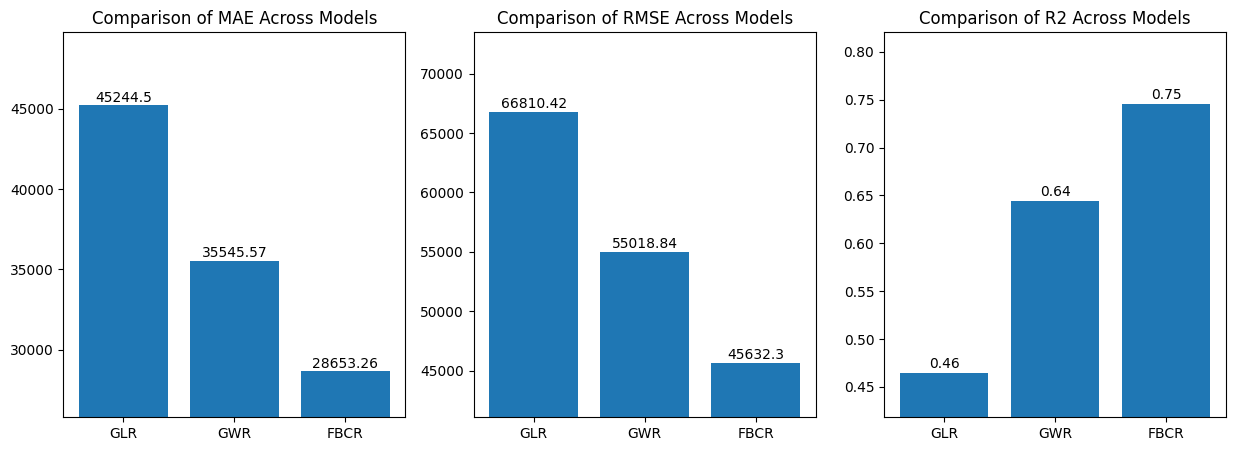

In [92]:
# Define the metrics for each model as a dictionary
metrics = {
    "GLR": [glr_mae, glr_rmse, glr_r2],
    "GWR": [gwr_mae, gwr_rmse, gwr_r2],
    "FBCR": [fbcr_mae, fbcr_rmse, fbcr_r2]
    
}

# Define the names of the metrics to be plotted
metric_names = ["MAE", "RMSE", "R2"]

# Create a grid of plots
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Loop through each metric and create a bar plot for each model
for i, metric in enumerate(metric_names):
    values = [metrics[model][i] for model in metrics.keys()]
    axs[i].bar(metrics.keys(), values)
    axs[i].set_xlabel("Model")
    axs[i].set_ylabel(metric)
    axs[i].set_title("Comparison of {} Across Models".format(metric))
    axs[i].set_ylim([min(values) * 0.9, max(values) * 1.1])
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    for j, v in enumerate(values):
        if metric == "R2":
            axs[i].text(j, v + 0.005, str(round(v, 2)), ha='center')
        elif metric == "MAE":
            axs[i].text(j, v + 200, str(round(v, 2)), ha='center')
        else:
            axs[i].text(j, v + 350, str(round(v, 2)), ha='center')

    

# Display the plots
plt.show()

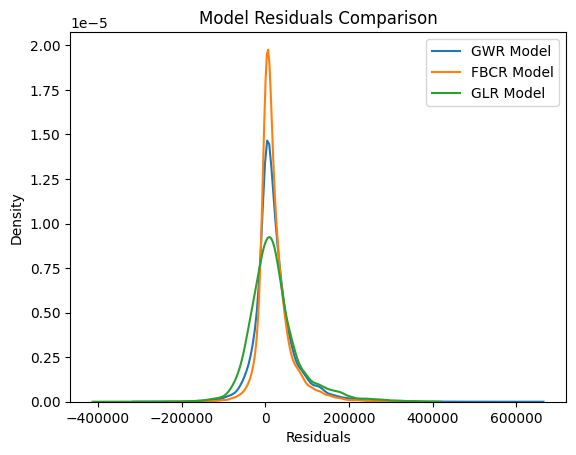

In [93]:
# Analyze residuals using a histogram and density plot
gwr_residuals = gwr_actual["actual"] - gwr_actual["predicted"]
fbcr_residuals = fbcr_actual["actual"] - fbcr_actual["predicted"]
glr_residuals = glr_actual["actual"] - glr_actual["predicted"]

sns.kdeplot(gwr_residuals, label="GWR Model")
sns.kdeplot(fbcr_residuals, label="FBCR Model")
sns.kdeplot(glr_residuals, label="GLR Model")
plt.title("Model Residuals Comparison")
plt.xlabel("Residuals")
plt.legend()
plt.show()

## Training Model Performance Metrics Diagnostics

In [50]:
# Load the CSV files
gwr_df = pd.read_csv("../database/predicted_data/gwr_predicted.csv")
fbcr_df = pd.read_csv("../database/predicted_data/fbcr_predicted.csv")

In [51]:
# Calculate the performance metrics for each model
glr_mae = mean_absolute_error(glr_df["price"], glr_df["PREDICTED"])
glr_rmse = mean_squared_error(glr_df["price"], glr_df["PREDICTED"], squared=False)
glr_r2 = r2_score(glr_df["price"], glr_df["PREDICTED"])

gwr_mae = mean_absolute_error(gwr_df["price"], gwr_df["PREDICTED"])
gwr_rmse = mean_squared_error(gwr_df["price"], gwr_df["PREDICTED"], squared=False)
gwr_r2 = r2_score(gwr_df["price"], gwr_df["PREDICTED"])

fbcr_mae = mean_absolute_error(fbcr_df["PRICE"], fbcr_df["PREDICTED"])
fbcr_rmse = mean_squared_error(fbcr_df["PRICE"], fbcr_df["PREDICTED"], squared=False)
fbcr_r2 = r2_score(fbcr_df["PRICE"], fbcr_df["PREDICTED"])

# Print the results
print("GLR: MAE={}, RMSE={}, R2={}".format(glr_mae, glr_rmse, glr_r2))
print("GWR: MAE={}, RMSE={}, R2={}".format(gwr_mae, gwr_rmse, gwr_r2))
print("FBCR: MAE={}, RMSE={}, R2={}".format(fbcr_mae, fbcr_rmse, fbcr_r2))

GLR: MAE=30423.962843358757, RMSE=46278.412493550306, R2=0.6666615088218144
GWR: MAE=27032.122071295522, RMSE=41258.582087686635, R2=0.7400540486294145
FBCR: MAE=14053.22613003116, RMSE=22733.53833832878, R2=0.9192043740691891


## Scatter-plots actual price vs predicted

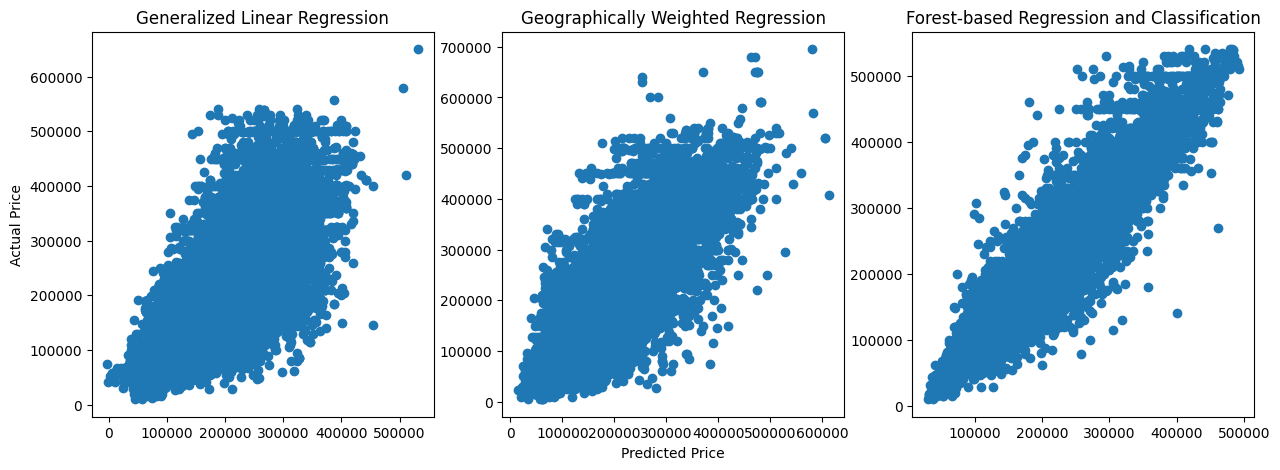

In [52]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Generalized Linear Regression model
axs[0].scatter(glr_df["PREDICTED"], glr_df["price"])
axs[0].set_title("Generalized Linear Regression")
axs[0].set_ylabel("Actual Price")

# Geographically Weighted Regression model
axs[1].scatter(gwr_df["PREDICTED"], gwr_df["price"])
axs[1].set_title("Geographically Weighted Regression")
axs[1].set_xlabel("Predicted Price")

# Forest-based Regression and Classification model
axs[2].scatter(fbcr_df["PREDICTED"], fbcr_df["PRICE"])
axs[2].set_title("Forest-based Regression and Classification")

plt.show()

## Distribution measurement

/var/folders/31/mgjvydd530n_q8xd9pnv0wrc0000gq/T/ipykernel_62393/4133878848.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


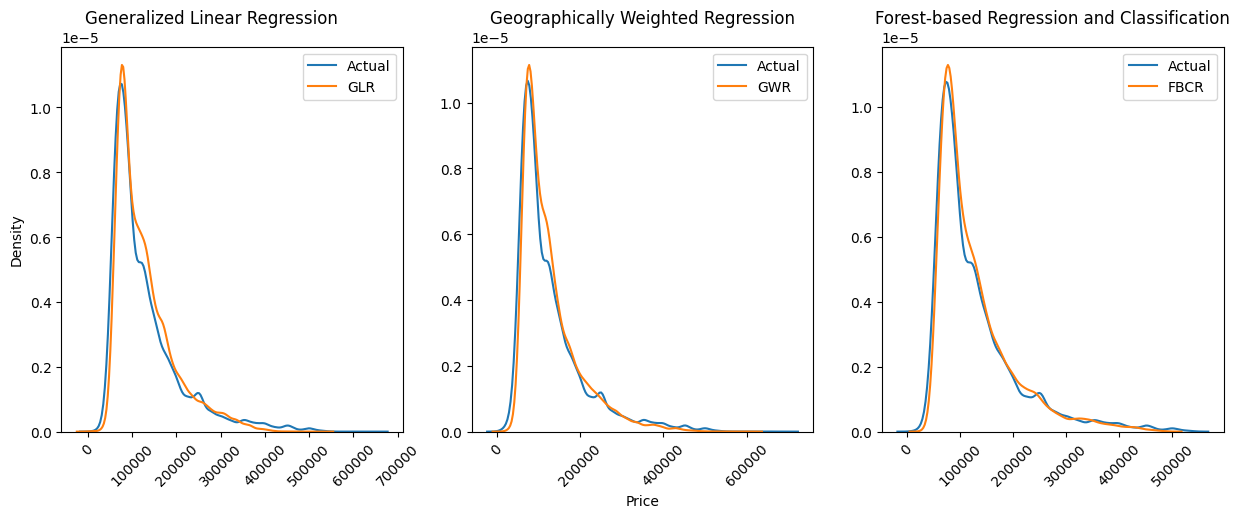

In [55]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Generalized Linear Regression model
sns.kdeplot(data=glr_df, x="price", label="Actual", ax=axs[0], legend=True)
sns.kdeplot(data=glr_df, x="PREDICTED", label="GLR", ax=axs[0], legend=True)
axs[0].set_title("Generalized Linear Regression        ")
axs[0].set_xlabel('')
axs[0].legend()

# Geographically Weighted Regression model
sns.kdeplot(data=gwr_df, x="price", label="Actual", ax=axs[1], legend=True)
sns.kdeplot(data=gwr_df, x="PREDICTED", label="GWR", ax=axs[1], legend=True)
axs[1].set_title("Geographically Weighted Regression")
axs[1].set_xlabel("Price")
axs[1].set_ylabel('')
axs[1].legend()

# Forest-based Regression and Classification model
sns.kdeplot(data=fbcr_df, x="PRICE", label="Actual", ax=axs[2], legend=True)
sns.kdeplot(data=fbcr_df, x="PREDICTED", label="FBCR", ax=axs[2], legend=True)
axs[2].set_title("Forest-based Regression and Classification")
axs[2].set_xlabel("")
axs[2].set_ylabel('')
axs[2].legend()

# Rotate x-axis tick labels by 45 degrees
for ax in axs:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# Display the plots
plt.show()

### Model comparison

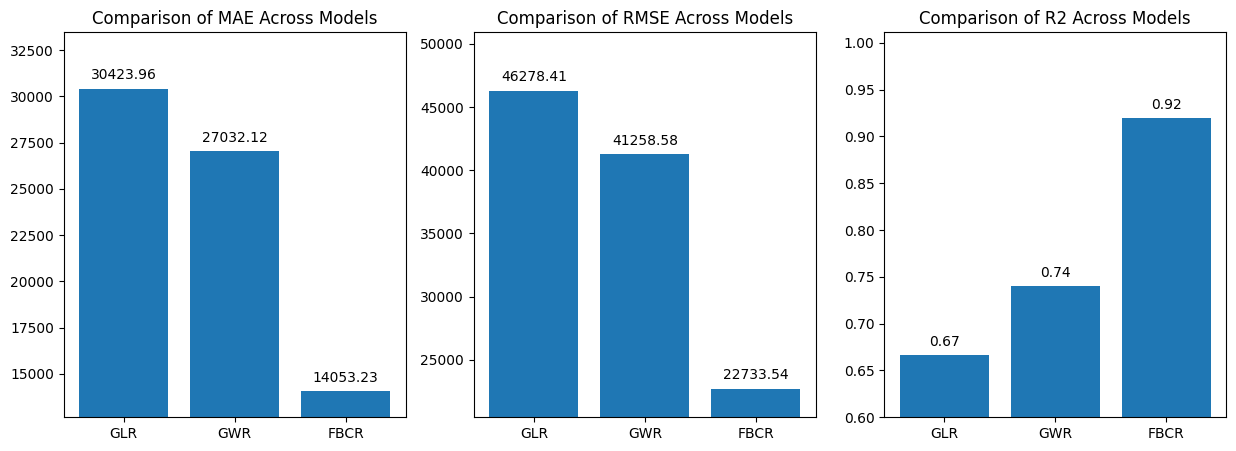

In [54]:
# Define the metrics for each model as a dictionary
metrics = {
    "GLR": [glr_mae, glr_rmse, glr_r2],
    "GWR": [gwr_mae, gwr_rmse, gwr_r2],
    "FBCR": [fbcr_mae, fbcr_rmse, fbcr_r2]
}

# Define the names of the metrics to be plotted
metric_names = ["MAE", "RMSE", "R2"]

# Create a grid of plots
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Loop through each metric and create a bar plot for each model
for i, metric in enumerate(metric_names):
    values = [metrics[model][i] for model in metrics.keys()]
    axs[i].bar(metrics.keys(), values)
    axs[i].set_xlabel("Model")
    axs[i].set_ylabel(metric)
    axs[i].set_title("Comparison of {} Across Models".format(metric))
    axs[i].set_ylim([min(values) * 0.9, max(values) * 1.1])
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    for j, v in enumerate(values):
        if metric == "R2":
            axs[i].text(j, v + 0.01, str(round(v, 2)), ha='center')
        elif metric == "MAE":
            axs[i].text(j, v + 500, str(round(v, 2)), ha='center')
        else:
            axs[i].text(j, v + 750, str(round(v, 2)), ha='center')

    

# Display the plots
plt.show()